In [97]:
# dataset cleaning by loss percentile (confident-learning style):
# the trained model scores every source page with CE loss of the "upright" (0 deg) label;
# pages above the percentile threshold are likely rotated in the source or garbage
CKPT        = "checkpoints/best.pt"
DATA_DIR    = "/mnt/DATA2/varlamova/HTR/trocr/data/texts/hwr200/texts"
CLEAN_LIST  = "clean_paths_2.txt"    # output: paths that survive the filter
SCORES_JSON = "noise_scores_2.json"  # cache of computed scores
PERCENTILE  = 75                   # drop pages above this loss percentile
BATCH_SIZE  = 32
DEVICE      = "cuda"               # falls back to cpu in the next cell if unavailable

In [98]:
import json
import torch
from pathlib import Path
from PIL import Image, ImageFile, UnidentifiedImageError
from torchvision import transforms as T
from doctr.models.classification import mobilenet_v3_small_page_orientation

ImageFile.LOAD_TRUNCATED_IMAGES = True
CLASSES = [0, -90, 180, 90]
DEVICE = DEVICE if torch.cuda.is_available() else "cpu"

preprocess = T.Compose([
    T.Resize(511, max_size=512),
    T.CenterCrop(512),
    T.ToTensor(),
    T.Normalize(mean=[0.694, 0.695, 0.693], std=[0.299, 0.296, 0.301]),
])

model = mobilenet_v3_small_page_orientation(pretrained=False)
model.load_state_dict(torch.load(CKPT, map_location="cpu"))
model = model.to(DEVICE).eval()

paths = sorted(p for p in Path(DATA_DIR).rglob("*")
               if p.is_file() and p.suffix.lower() in (".jpg", ".jpeg", ".png"))
print(len(paths), "pages")

33049 pages


In [99]:
# score every page: CE loss of the "upright" hypothesis (class 0) on the unrotated image.
# results are cached in SCORES_JSON, so the notebook can be re-run cheaply
import numpy as np
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

scores = {}
if Path(SCORES_JSON).exists():
    with open(SCORES_JSON, encoding="utf-8") as f:
        scores = json.load(f)

todo = [p for p in paths if str(p) not in scores]
print(f"{len(todo)} pages to score, {len(scores)} cached")


class Pages(Dataset):
    def __init__(self, paths):
        self.paths = paths

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        try:
            img = Image.open(self.paths[i]).convert("RGB")
        except (UnidentifiedImageError, OSError):
            return None
        return i, preprocess(img)


def collate(batch):
    batch = [b for b in batch if b is not None]
    if not batch:
        return None
    idx, xs = zip(*batch)
    return torch.tensor(idx), torch.stack(xs)


dl = DataLoader(Pages(todo), batch_size=BATCH_SIZE, num_workers=4,
                pin_memory=True, collate_fn=collate)

with torch.no_grad():
    for batch in tqdm(dl):
        if batch is None:
            continue
        idx, x = batch
        logp = model(x.to(DEVICE)).log_softmax(-1).cpu()
        for j, i in enumerate(idx.tolist()):
            scores[str(todo[i])] = {
                "loss": float(-logp[j, 0]),                    # CE for label "0 degrees"
                "pred": CLASSES[int(logp[j].argmax())],
                "conf": float(logp[j].exp().max()),
            }

with open(SCORES_JSON, "w", encoding="utf-8") as f:
    json.dump(scores, f, ensure_ascii=False)
print(f"scored total: {len(scores)}")

1 pages to score, 33048 cached


100%|██████████| 1/1 [00:00<00:00,  5.97it/s]


scored total: 33048


p50: 0.000
p75: 0.001
p90: 10.616
p95: 15.241
p99: 19.936


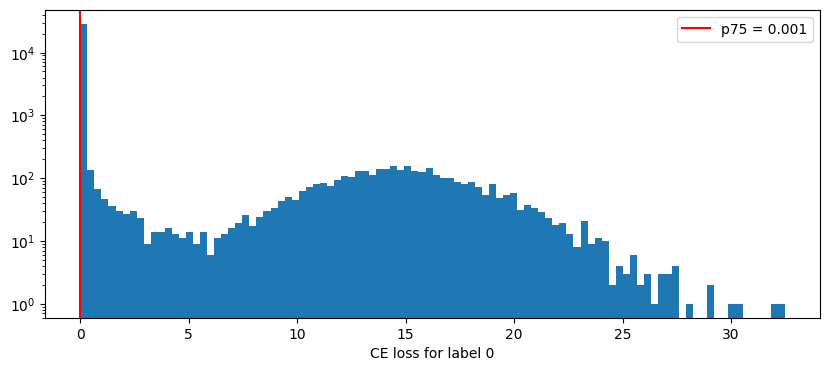

above threshold: 8262 of 33048


In [100]:
import matplotlib.pyplot as plt

losses = np.array([s["loss"] for s in scores.values()])
for q in (50, 75, 90, 95, 99):
    print(f"p{q}: {np.percentile(losses, q):.3f}")
thr = float(np.percentile(losses, PERCENTILE))

plt.figure(figsize=(10, 4))
plt.hist(losses, bins=100)
plt.axvline(thr, color="r", label=f"p{PERCENTILE} = {thr:.3f}")
plt.yscale("log"); plt.xlabel("CE loss for label 0"); plt.legend(); plt.show()
print(f"above threshold: {(losses > thr).sum()} of {len(losses)}")

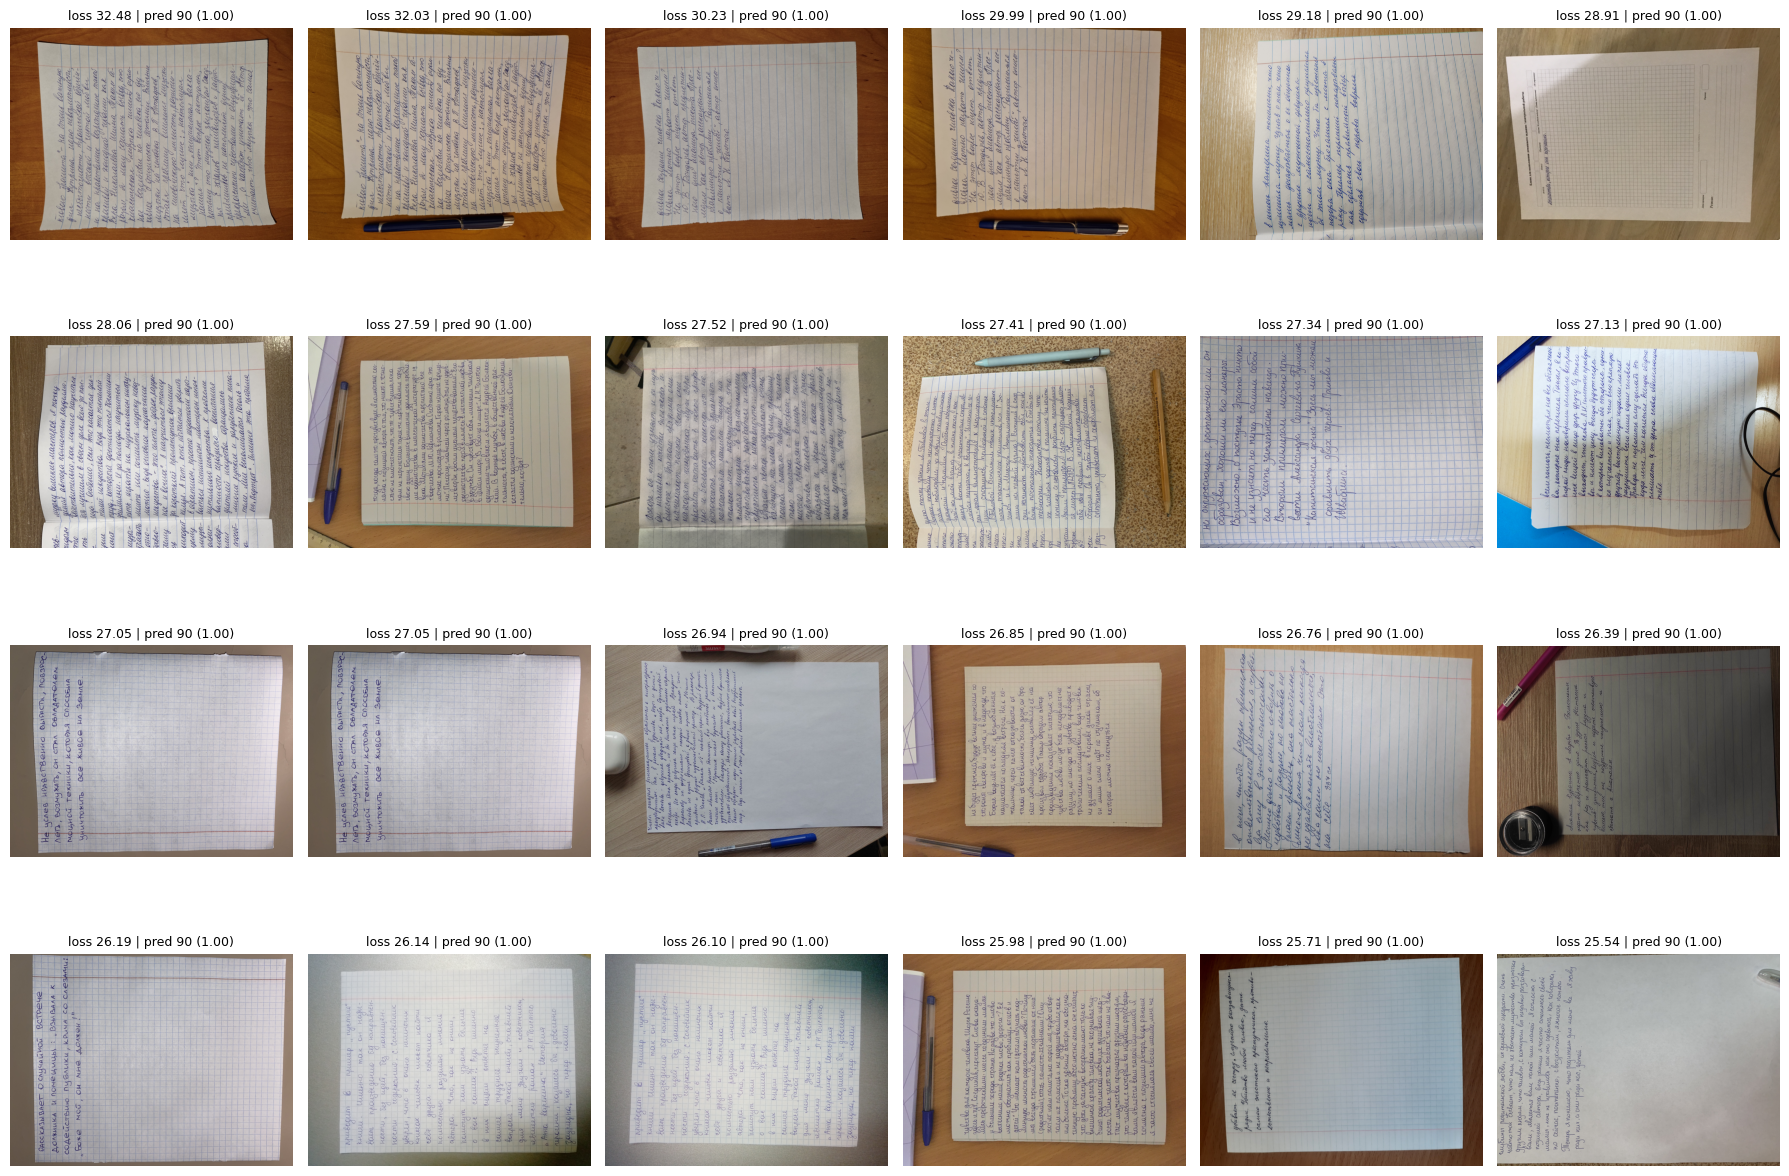

In [101]:
# eyeball the worst pages: high loss + confident pred != 0 => page is rotated in the source;
# high loss + low conf => garbage (blur, empty, not a page)
worst = sorted(scores.items(), key=lambda kv: -kv[1]["loss"])[:24]

fig, axes = plt.subplots(4, 6, figsize=(18, 13))
for ax, (path, s) in zip(axes.ravel(), worst):
    try:
        ax.imshow(Image.open(path).convert("RGB"))
    except Exception:
        pass
    ax.set_title(f"loss {s['loss']:.2f} | pred {s['pred']} ({s['conf']:.2f})", fontsize=9)
    ax.axis("off")
plt.tight_layout(); plt.show()

In [102]:
# write the cleaned file list for train.py (config: data.file_list)
keep = [p for p, s in scores.items() if s["loss"] <= thr]
Path(CLEAN_LIST).write_text("\n".join(keep), encoding="utf-8")
print(f"kept {len(keep)} / {len(scores)} pages -> {CLEAN_LIST}")

kept 24786 / 33048 pages -> clean_paths_2.txt


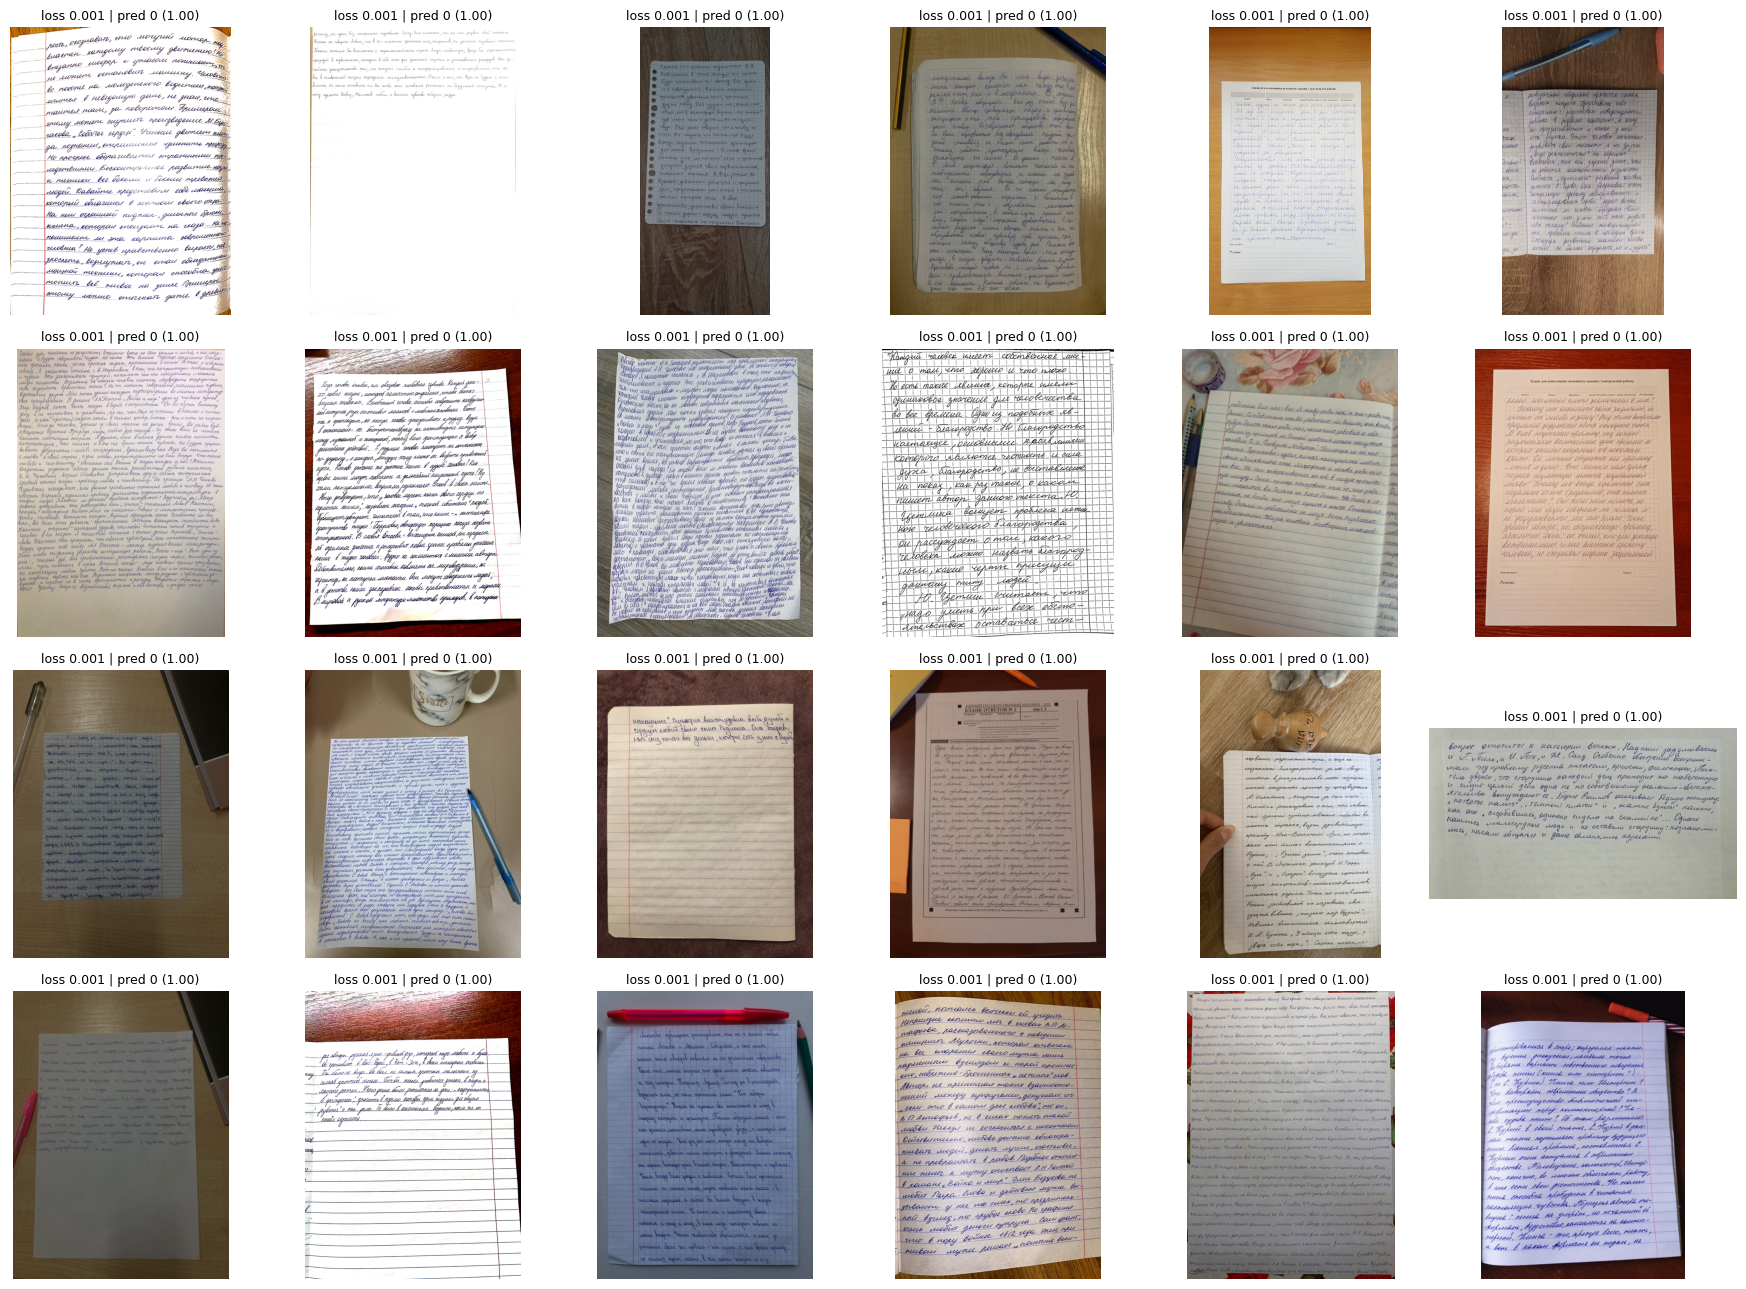

In [103]:
# оставленные фильтром (loss <= thr), отсортированы по убыванию лосса —
# это худшее из того, что уйдёт в обучение
kept = [kv for kv in scores.items() if kv[1]["loss"] <= thr]
kept.sort(key=lambda kv: -kv[1]["loss"])
batch = kept[:24]

fig, axes = plt.subplots(4, 6, figsize=(18, 13))
for ax, (path, s) in zip(axes.ravel(), batch):
    try:
        ax.imshow(Image.open(path).convert("RGB"))
    except Exception:
        pass
    ax.set_title(f"loss {s['loss']:.3f} | pred {s['pred']} ({s['conf']:.2f})", fontsize=9)
    ax.axis("off")
plt.tight_layout(); plt.show()

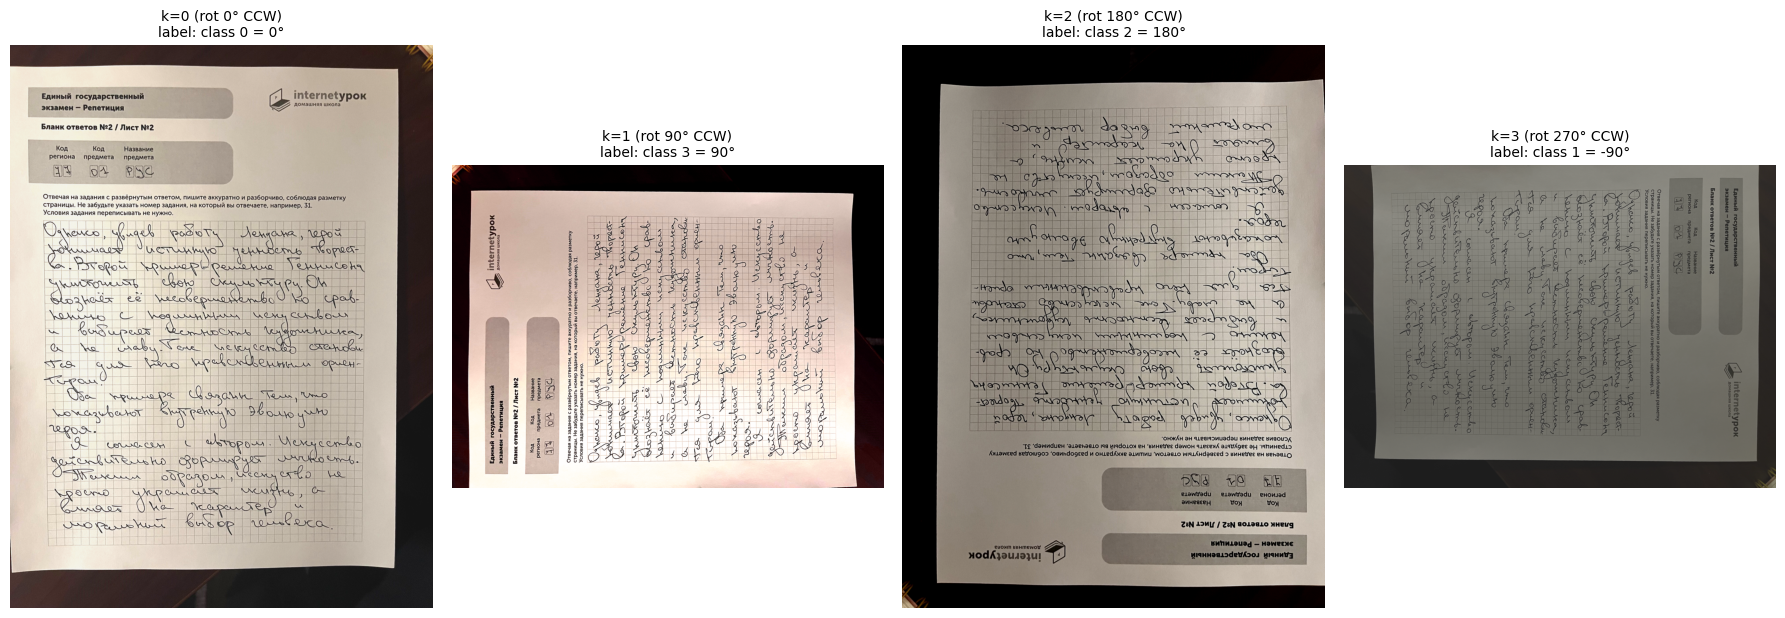

In [104]:
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms as T

IMG = "/mnt/DATA2/dorin/images/test_htr/1(1).jpg"  # любая страница

CLASSES = [0, -90, 180, 90]
K_TO_CLASS = [0, 3, 2, 1]
PIL_ROT = [None, Image.Transpose.ROTATE_90, Image.Transpose.ROTATE_180, Image.Transpose.ROTATE_270]

color_aug = T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05)

src = Image.open(IMG).convert("RGB")

fig, axes = plt.subplots(1, 4, figsize=(18, 6))
for k, ax in enumerate(axes):
    img = color_aug(src)                    # каждый раз новый случайный цвет — как в трейне
    if PIL_ROT[k] is not None:
        img = img.transpose(PIL_ROT[k])
    cls = K_TO_CLASS[k]
    ax.imshow(img)
    ax.set_title(f"k={k} (rot {90*k}° CCW)\nlabel: class {cls} = {CLASSES[cls]}°", fontsize=10)
    ax.axis("off")
plt.tight_layout(); plt.show()